# 2.1

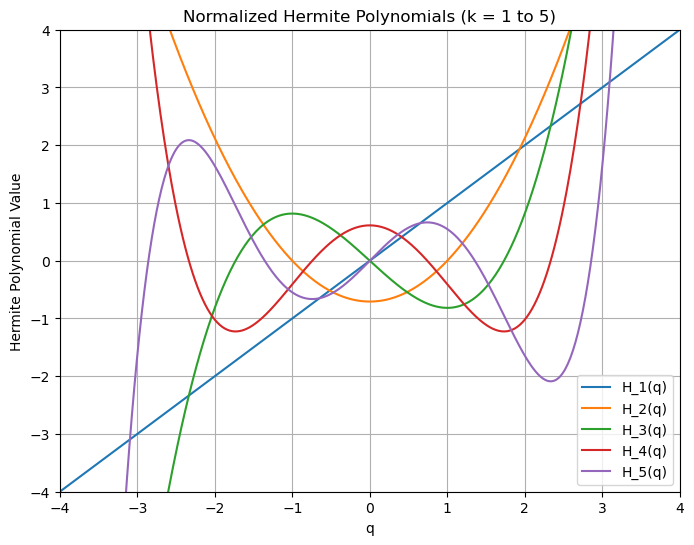

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
## TODO can remove state loading.., set the seed instead for repeatability 
import pickle

with open("rng_state.pkl", "rb") as f:
    state = pickle.load(f)

np.random.set_state(state)
### 

# import the provided Hermite polynomial function
from ASE379L_UQ_Polynomials import hermitePoly  

# create q values
q = np.linspace(-4,4,500)

# compute Hermite polynomials up to degree 5
polys = hermitePoly(q,5)

plt.figure(figsize=(8,6))

for k in range(1,6):
    plt.plot(q, polys[k,:], label=f"H_{k}(q)")

plt.xlabel("q")
plt.ylabel("Hermite Polynomial Value")
plt.title("Normalized Hermite Polynomials (k = 1 to 5)")

plt.ylim([-4,4])   
plt.xlim([-4,4])

plt.grid()
plt.legend()

plt.show()

# 2.2

In [71]:
from numpy.polynomial.hermite import hermgauss
R = 10
nodes, weights = hermgauss(R)

# convert quadrature for expectation under N(0,1)
weights = weights / np.sqrt(np.pi)
q = np.sqrt(2) * nodes

# evaluate normalized Hermite polynomials
polys = hermitePoly(q,5)

psi2 = polys[2,:]
psi3 = polys[3,:]

E_psi2psi2 = np.sum(weights * psi2 * psi2)
E_psi2psi3 = np.sum(weights * psi2 * psi3)

print("R =",R)
print("E[psi2 psi2] =",E_psi2psi2)
print("E[psi2 psi3] =",E_psi2psi3)

R = 10
E[psi2 psi2] = 1.0000000000000004
E[psi2 psi3] = -2.905661822261152e-17


Standard probabilists' Hermite polynomials satisfy the orthogonality relation

$$
E[He_i(Q)He_j(Q)] =
\begin{cases}
i! & i=j \\
0 & i\neq j
\end{cases}
$$

for a standard normal random variable $Q \sim N(0,1)$.  
Thus, the polynomials are orthogonal but not normalized since

$$
E[He_i(Q)^2] = i!.
$$

To obtain an orthonormal basis, we define the normalized Hermite polynomials as

$$
\psi_k(Q) = \frac{He_k(Q)}{\sqrt{k!}}.
$$

The inner product between two normalized polynomials becomes

$$
E[\psi_i(Q)\psi_j(Q)]
=
\frac{1}{\sqrt{i!j!}}
E[He_i(Q)He_j(Q)].
$$

Substituting the orthogonality relation gives

$$
E[\psi_i(Q)\psi_j(Q)] = \delta_{ij},
$$

where $\delta_{ij}$ is the Kronecker delta defined as

$$
\delta_{ij} =
\begin{cases}
1 & i=j \\
0 & i\neq j
\end{cases}.
$$

Therefore, the normalized Hermite polynomials form an orthonormal basis with respect to the standard normal probability measure.

# 2.3

In [72]:
N = 100
mean_true = 0
var_true = 1

Q = np.random.normal(mean_true, np.sqrt(var_true), N)
t = 1
u0 = 1

def u(Q):
    return u0*np.exp(-Q*t)   # since u(1,Q) = exp(-Q)

u_vals = u(Q)

mean_emp = np.mean(u_vals)
var_emp = np.var(u_vals)
mean_true_u = np.exp(1/2)
var_true_u = np.exp(1) * (np.exp(1)-1)
print(f"For N = {N} samples:")
print("Analytic mean =", mean_true_u)
print("Analytic variance =", var_true_u)

print("Empirical mean =", mean_emp)
print("Empirical variance =", var_emp)

For N = 100 samples:
Analytic mean = 1.6487212707001282
Analytic variance = 4.670774270471604
Empirical mean = 1.6217621037045336
Empirical variance = 9.748606402168827


To recheck the analytic meean/variance calculations, we increase the number of random samples used in the MC simulation and check if the empirical mean and variance determined using the random MC samples converges to the analytic mean/variance of u (which is does):

In [73]:
N = 1_000_000

Q_large = np.random.normal(mean_true, np.sqrt(var_true), N)
u_vals_large = u(Q_large)

mean_emp_large = np.mean(u_vals_large)
var_emp_large = np.var(u_vals_large)

print(f"For N = {N} samples:")
print("Empirical mean =", mean_emp_large)
print("Empirical variance =", var_emp_large)
print("Analytic mean =", mean_true_u)
print("Analytic variance =", var_true_u)

For N = 1000000 samples:
Empirical mean = 1.643765096411298
Empirical variance = 4.584158748422347
Analytic mean = 1.6487212707001282
Analytic variance = 4.670774270471604


# 2.4

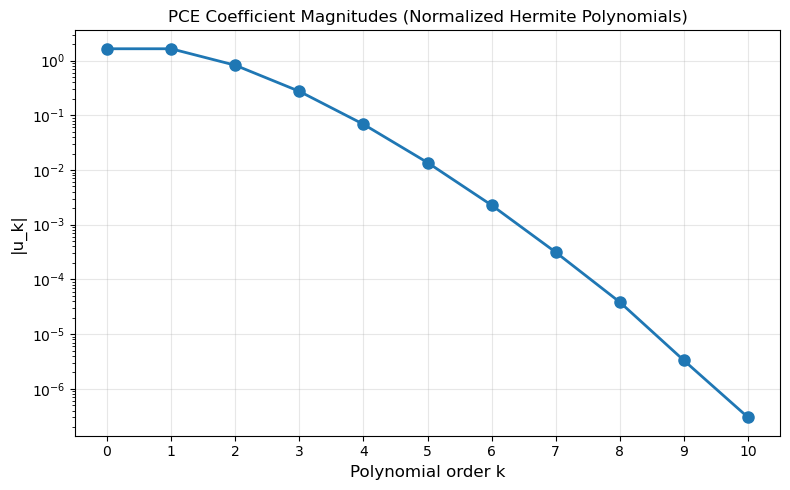


PCE Coefficients:
u_0 = 1.648720e+00
u_1 = -1.648701e+00
u_2 = 8.243389e-01
u_3 = -2.747124e-01
u_4 = 6.866069e-02
u_5 = -1.368487e-02
u_6 = 2.274305e-03
u_7 = -3.138299e-04
u_8 = 3.843096e-05
u_9 = -3.298916e-06
u_10 = 3.007313e-07


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.hermite import hermvander

K = 10

# Scale Q for probabilist's Hermite polynomials
# For probabilist's: ψ_k(q) = 2^(-k/2) * H_k(q/√2)
Q_scaled = Q / np.sqrt(2)  # Transform for physicist's Hermite

# Vandermonde matrix for physicist's Hermite polynomials
Psi_phys = hermvander(Q_scaled, K)  # shape (N, K+1)

# Convert to probabilist's Hermite polynomials
Psi = np.zeros_like(Psi_phys)
for k in range(K+1):
    # ψ_k(q) = 2^(-k/2) * H_k(q/√2)
    Psi[:, k] = Psi_phys[:, k] * (2**(-k/2))

# Solve for coefficients using least squares
coeffs, *_ = np.linalg.lstsq(Psi, u_vals, rcond=None)


# Plot coefficient magnitudes
k_vals = np.arange(K+1)

plt.figure(figsize=(8,5))
plt.semilogy(k_vals, np.abs(coeffs), 'o-', linewidth=2, markersize=8)
plt.xlabel("Polynomial order k", fontsize=12)
plt.ylabel("|u_k|", fontsize=12)
plt.title("PCE Coefficient Magnitudes (Normalized Hermite Polynomials)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(k_vals)
plt.tight_layout()
plt.show()

# Optional: Print coefficients for inspection
print("\nPCE Coefficients:")
for k, coeff in enumerate(coeffs):
    print(f"u_{k} = {coeff:.6e}")

### mechanical construction of matrices/least squares (same result as above)


PCE Coefficients (Probabilist's Hermite):
u_0 = 1.648720e+00
u_1 = -1.648701e+00
u_2 = 8.243389e-01
u_3 = -2.747124e-01
u_4 = 6.866069e-02
u_5 = -1.368487e-02
u_6 = 2.274305e-03
u_7 = -3.138299e-04
u_8 = 3.843096e-05
u_9 = -3.298916e-06
u_10 = 3.007313e-07


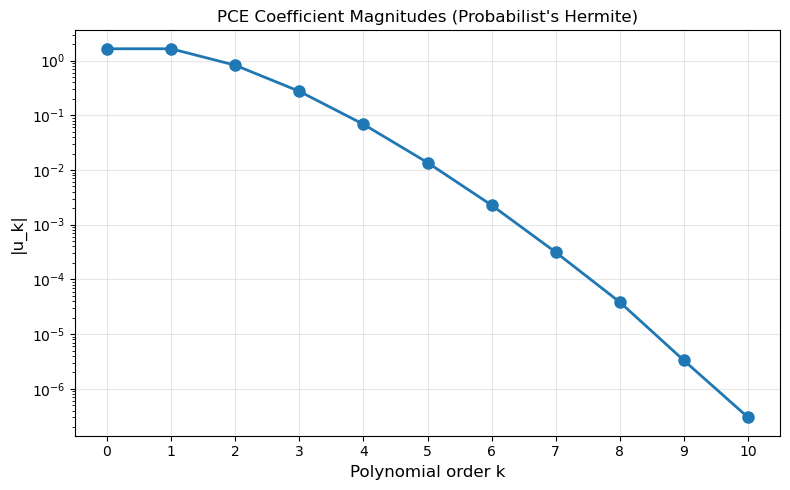

In [75]:
import numpy as np
import matplotlib.pyplot as plt

K = 10
N = len(Q)

# Initialize Psi matrix for probabilist's Hermite polynomials
Psi = np.zeros((N, K+1))

# He0(x) = 1
Psi[:, 0] = 1.0

# He1(x) = x
Psi[:, 1] = Q  # Directly use Q (no scaling needed for probabilist's!)

# Probabilist's Hermite recurrence: He_{k+1}(x) = x * He_k(x) - k * He_{k-1}(x)
for k in range(1, K):
    # This builds He_{k+1} from He_k and He_{k-1}
    Psi[:, k+1] = Q * Psi[:, k] - k * Psi[:, k-1]

# Now Psi contains the probabilist's Hermite polynomials evaluated at Q
# No additional scaling needed!

# Solve normal equations
A = Psi.T @ Psi
b = Psi.T @ u_vals
coeffs = np.linalg.solve(A, b)

# Print coefficients
print("\nPCE Coefficients (Probabilist's Hermite):")
for k, coeff in enumerate(coeffs):
    print(f"u_{k} = {coeff:.6e}")

# Plot
k_vals = np.arange(K+1)
plt.figure(figsize=(8,5))
plt.semilogy(k_vals, np.abs(coeffs), 'o-', linewidth=2, markersize=8)
plt.xlabel("Polynomial order k", fontsize=12)
plt.ylabel("|u_k|", fontsize=12)
plt.title("PCE Coefficient Magnitudes (Probabilist's Hermite)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(k_vals)
plt.tight_layout()
plt.show()

As k increases, $|u_k|$ quickly decreases (logarthamically), indicating that higher-order terms contribute less to the solution. This suggests the PCE converges as we add more terms, with the series being dominated by lower-order polynomials (as is similar to any polynomial expansion or PCA/SVD modal decomposition).

# 2.5

In [76]:
pce_mean = coeffs[0]
pce_variance = np.sum(coeffs[1:]**2)

print(f"PCE with K = {K} ")
print("PCE mean =", pce_mean)
print("PCE variance =", pce_variance)

print(f"MC with N = {N} samples:")
print("Empirical mean =", mean_emp)
print("Empirical variance =", var_emp)

print("Analytic mean =", mean_true_u)
print("Analytic variance =", var_true_u)



PCE with K = 10 
PCE mean = 1.6487204185181616
PCE variance = 3.4781221374859963
MC with N = 100 samples:
Empirical mean = 1.6217621037045336
Empirical variance = 9.748606402168827
Analytic mean = 1.6487212707001282
Analytic variance = 4.670774270471604


In [79]:
print((pce_mean-mean_true_u)/mean_true_u)
print((mean_emp-mean_true_u)/mean_true_u)

print((pce_variance-var_true_u)/var_true_u)
print((var_emp-var_true_u)/var_true_u)

-5.16874490365914e-07
-0.01635156134314107
-0.2553435606009679
1.0871499750692337


The PCE-determined mean (1.648720) matches the analytic solution (1.648721) to within 10⁻⁶ ($O(10^{-6})$ error), demonstrating exceptional accuracy. The PCE variance (3.478122) shows more deviation from the true variance (4.670774) (25% error), likely due to insufficient samples (N=100) for accurately estimating all 11 coefficients via least squares.

In contrast, the Monte Carlo approximation using the same 100 samples yields a mean with 1.6% error and a variance that is completely unreliable (off by 109% error). This stark comparison illustrates the superior efficiency of polynomial chaos methods: PCE extracts far more information from each sample by exploiting the smooth structure of the response function. While MC would require tens of thousands of samples to achieve comparable accuracy (due to the slow $sqrt(n)$ convergence rate), PCE achieves near-exact mean estimates with only 100 samples. The variance estimate could also be further improved by increasing the number of least squares samples.

In general, the variance estimates show more error than the mean estimates since variance is a nonlinear function while mean is a linear (easily capturable) meeasure. 

# 2.6

PCE Coefficients via Gauss-Hermite Quadrature (R=20)
u_0 = 1.6487212707001286
u_1 = -1.648721270700129
u_2 = 1.1658219907985627
u_3 = -0.6730876402147361
u_4 = 0.3365438201073678
u_5 = -0.15050697183350628
u_6 = 0.06144421395392113
u_7 = -0.023223729946560193
u_8 = 0.008210828464829447
u_9 = -0.0027369428216098206
u_10 = 0.0008654973141930021
PCE w/ Gauss-Hermite Quadrature Mean = 1.6487212707001286
PCE w/ Gauss-Hermite Quadrature Variance = 4.6707741962281
   Relative Error in Mean: 2.69e-14%
   Relative Error in Variance: 1.59e-06%

Least Squares PCE (from Problem 2.4):
Mean = 1.6487204185181616
Variance = 3.4781221374859963
   Relative Error in Mean: 5.17e-05%
   Relative Error in Variance: 2.55e+01%

Analytic Solution:
Mean = 1.6487212707001282
Variance = 4.670774270471606


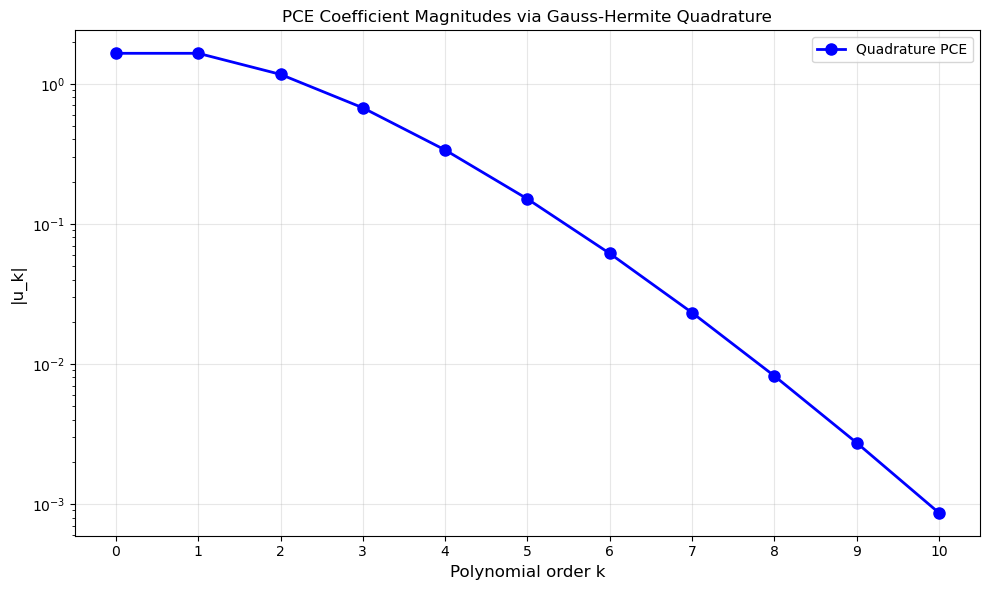


Verifying orthogonality (should be ~1 on diagonal, 0 elsewhere):
E[ψ_i ψ_j] for i,j=0..2:
[[ 1.00000000e+00  6.83417179e-18  2.50103296e-16]
 [ 6.83417179e-18  1.00000000e+00  4.40205592e-19]
 [ 2.50103296e-16 -6.49869493e-18  1.00000000e+00]]


In [93]:
def probabilist_hermgauss(R):
    """Get probabilist's Gauss-Hermite nodes and weights"""
    nodes_phys, weights_phys = hermgauss(R)
    nodes = nodes_phys * np.sqrt(2)
    weights = weights_phys / np.sqrt(np.pi)
    return nodes, weights

# Parameters
K = 10  # PCE order
R = 20  # Quadrature nodes (sufficiently large)

# Get quadrature nodes and weights
q_r, w_r = probabilist_hermgauss(R)

# Evaluate u at quadrature points
u_q = np.exp(-q_r)

# Evaluate Hermite polynomials at quadrature points
# hermitePoly returns array of shape (K+1, R) where first index is degree
psi_vals = hermitePoly(q_r, K)  # Shape: (K+1, R)

# Compute PCE coefficients using quadrature
# u_k = sum(w_r * u(q_r) * psi_k(q_r))
coeffs_quad = np.zeros(K+1)
for k in range(K+1):
    coeffs_quad[k] = np.sum(w_r * u_q * psi_vals[k, :])

# Compute mean and variance from quadrature coefficients
mean_quad = coeffs_quad[0]
variance_quad = np.sum(coeffs_quad[1:]**2)

# Analytic solutions
mean_true = np.exp(0.5)
variance_true = np.exp(2) - np.exp(1)

# Print results
print("=" * 60)
print("PCE Coefficients via Gauss-Hermite Quadrature (R={})".format(R))
print("=" * 60)
for k, coeff in enumerate(coeffs_quad):
    print(f"u_{k} = {coeff}")
print("=" * 60)
print(f"PCE w/ Gauss-Hermite Quadrature Mean = {mean_quad}")
print(f"PCE w/ Gauss-Hermite Quadrature Variance = {variance_quad}")

rel_error_mean_quad = abs(mean_quad - mean_true) / abs(mean_true) * 100
rel_error_var_quad = abs(variance_quad - variance_true) / abs(variance_true) * 100
print(f"   Relative Error in Mean: {rel_error_mean_quad:.2e}%")
print(f"   Relative Error in Variance: {rel_error_var_quad:.2e}%")
print()

print("Least Squares PCE (from Problem 2.4):")
print(f"Mean = {pce_mean}")
print(f"Variance = {pce_variance}")
rel_error_mean_ls = abs(pce_mean - mean_true) / abs(mean_true) * 100
rel_error_var_ls = abs(pce_variance - variance_true) / abs(variance_true) * 100
print(f"   Relative Error in Mean: {rel_error_mean_ls:.2e}%")
print(f"   Relative Error in Variance: {rel_error_var_ls:.2e}%")
print()
print("Analytic Solution:")
print(f"Mean = {mean_true}")
print(f"Variance = {variance_true}")



# Plot coefficient magnitudes
k_vals = np.arange(K+1)
plt.figure(figsize=(10, 6))
plt.semilogy(k_vals, np.abs(coeffs_quad), 'bo-', linewidth=2, markersize=8, 
             label='Quadrature PCE')


plt.xlabel("Polynomial order k", fontsize=12)
plt.ylabel("|u_k|", fontsize=12)
plt.title("PCE Coefficient Magnitudes via Gauss-Hermite Quadrature", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(k_vals)
plt.tight_layout()
plt.show()

# Verify orthogonality (optional check)
print("\nVerifying orthogonality (should be ~1 on diagonal, 0 elsewhere):")
orthog_check = np.zeros((K+1, K+1))
for i in range(K+1):
    for j in range(K+1):
        orthog_check[i,j] = np.sum(w_r * psi_vals[i,:] * psi_vals[j,:])
print("E[ψ_i ψ_j] for i,j=0..2:")
print(orthog_check[:3, :3])

The quadrature-based PCE coefficients yield means and variances that, which match the analytic solution to within 2.69e-14% and 1.59e-06% relative error respectively—effectively machine precision. In contrast, the least squares PCE using 100 samples produces a mean of 1.648 (5.17e-05% error) that is reasonably accurate, but its variance of 3.478 shows a substantial 25.5% relative error. The least squares solution severely underestimates the variance. This dramatic difference highlights that while least squares can adequately capture the mean with limited samples, accurately estimating higher-order moments like variance requires either significantly more samples or a more efficient approaches. The quadrature method achieves near-exact results because it leverages the known functional form of u(q) and the orthogonality properties of the Hermite polynomials through precise numerical integration, whereas least squares suffers from sampling error in the coefficient estimates